In [2]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
import sys
import os
#My jupyter notebook has some problems in finding the right folder, that's why I put this line below
os.chdir(r'C:\Users\vitto\OneDrive\Desktop\MyProject')
sys.path.append(os.path.abspath("code"))
from pywt import scale2frequency
from pywt import cwt
import lfp_functions as lf

In [3]:
# Import the data from data/moving_lfp.pickle
with open('data/moving_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']
print(f'Loaded {len(lfp)/sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz')

Loaded 600.133 seconds of LFP, sampled at 1000.0 Hz


Text(0, 0.5, 'voltage (mV)')

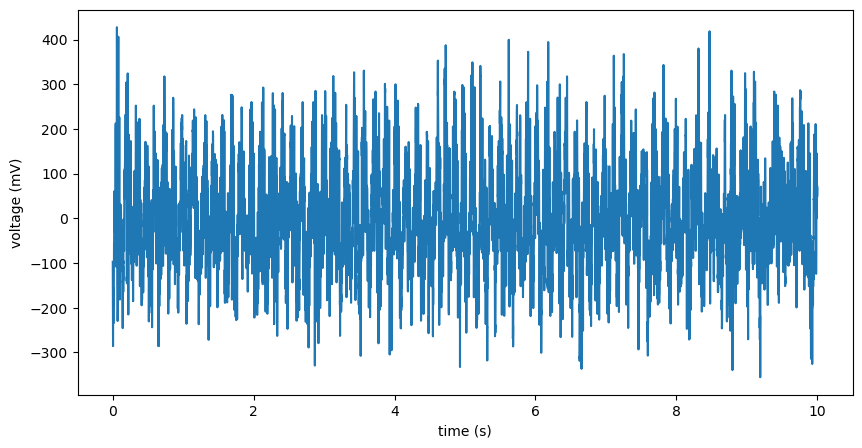

In [4]:
# I select a period of 10 seconds of the signal
start = 0  # in seconds
end = 10   # in seconds

sig = lfp[int(start*sampling_rate):int(end*sampling_rate)]
sig = sig - np.mean(sig)  # get rid of 0 frequency component

plt.figure(figsize=(10,5))
plt.plot(np.linspace(start, end, len(sig)), sig)
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')

Text(0, 0.5, 'frequency (Hz)')

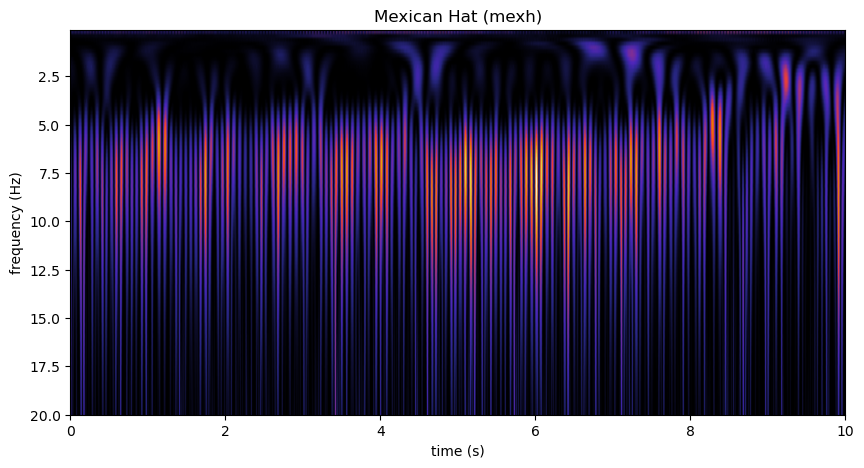

In [5]:
# Spectrogram with the Mexican Hat wavelet - real wavelet
frequencies = np.linspace(0.1, 20, 100)/sampling_rate
wavelet = 'mexh'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate)

plt.figure(figsize=(10,5))
plt.title('Mexican Hat (mexh)')
plt.imshow(abs(cwtmatr)**2, extent=[start, end, frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')
plt.xlabel('time (s)')
plt.ylabel('frequency (Hz)')

Text(0, 0.5, 'frequency (Hz)')

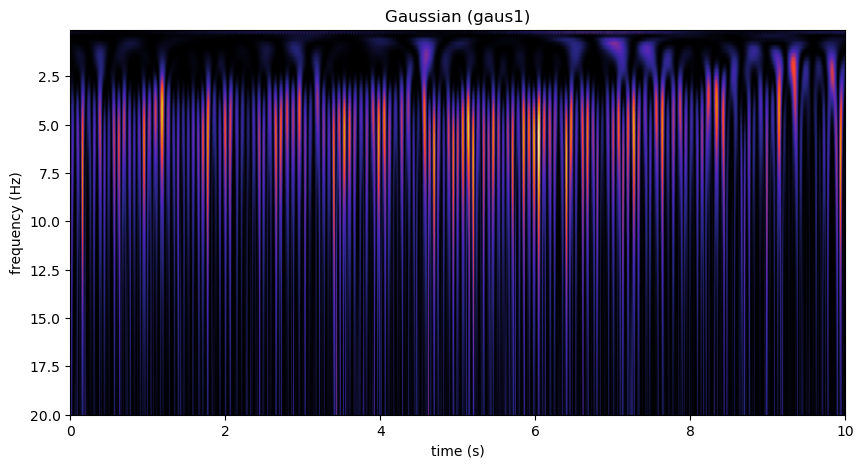

In [6]:
# Spectrogram with the Gaussian wavelet (gaus1) - real wavelet
frequencies = np.linspace(0.1, 20, 100)/sampling_rate
wavelet = 'gaus1'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate)

plt.figure(figsize=(10,5))
plt.title('Gaussian (gaus1)')
plt.imshow(abs(cwtmatr)**2, extent=[start, end, frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')
plt.xlabel('time (s)')
plt.ylabel('frequency (Hz)')

Text(0, 0.5, 'frequency (Hz)')

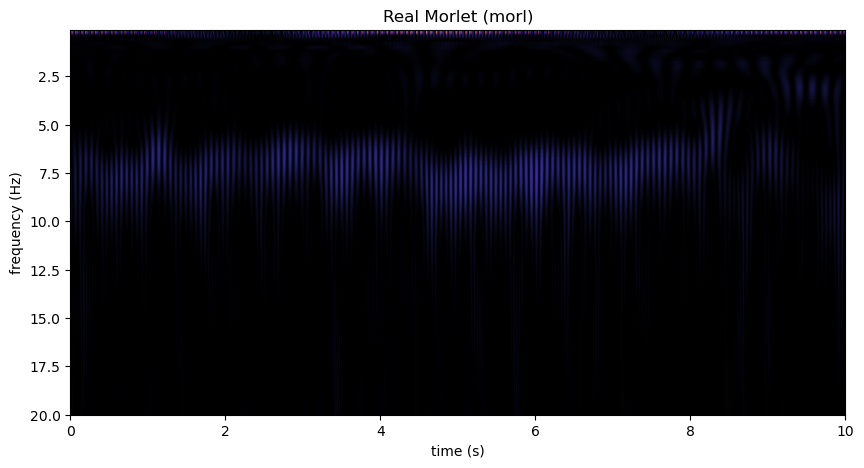

In [7]:
# Spectrogram with the real Morlet wavelet (morl) - real wavelet
frequencies = np.linspace(0.1, 20, 100)/sampling_rate
wavelet = 'morl'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate)

plt.figure(figsize=(10,5))
plt.title('Real Morlet (morl)')
plt.imshow(abs(cwtmatr)**2, extent=[start, end, frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')
plt.xlabel('time (s)')
plt.ylabel('frequency (Hz)')

Text(0, 0.5, 'frequency (Hz)')

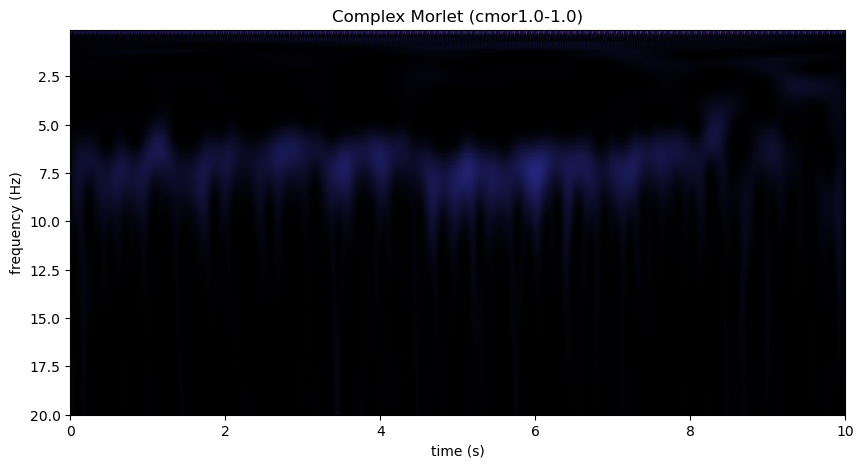

In [9]:
# Spectrogram with the complex Morlet wavelet (cmor1.0-1.0) for comparison
frequencies = np.linspace(0.1, 20, 100)/sampling_rate
wavelet = 'cmor1.0-1.0'
scales = scale2frequency(wavelet, frequencies)
cwtmatr, _ = cwt(sig, wavelet=wavelet, scales=scales,
                  sampling_period=1.0/sampling_rate)

plt.figure(figsize=(10,5))
plt.title('Complex Morlet (cmor1.0-1.0)')
plt.imshow(abs(cwtmatr)**2, extent=[start, end, frequencies[-1]*sampling_rate,
                         frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')
plt.xlabel('time (s)')
plt.ylabel('frequency (Hz)')

### Comments

The spectrograms computed with real wavelets mexh, gaus1, morl show rapid oscillations in the power trace over time, appearing noisy and less smooth compared to the complex Morlet result.

This happens because real wavelets are sensitive to the phase of the signal: as the signal oscillates, the convolution between a real wavelet and a sinusoidal signal alternates between positive and negative values, making the instantaneous power fluctuate at twice the signal frequency.

The complex Morlet wavelet, by contrast, has a real and an imaginary part that are 90° out of phase (a sine and a cosine). Taking the modulus of the complex coefficients gives the envelope of the oscillation, which is smooth and reflects the true instantaneous power. This makes the complex Morlet much better suited for tracking power changes over time.